# Quickstart

[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/etna-team/etna/master?filepath=examples/quickstart.ipynb)

In this introduction we will show how to make a simple forecast using ETNA library.

In [47]:
!pip install "etna[prophet]" -q
!pip uninstall prophet -y -q
!pip install "prophet>=1.1.5" -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 104.3 MB/s eta 0:00:00


In [ ]:
import warnings

warnings.filterwarnings("ignore")

Let's load and prepare the data.

In [1]:
#
# Шаг 1. Генерация данных
#
import numpy as np
import pandas as pd
from etna.datasets import TSDataset
from etna.transforms import (
    LogTransform,
    LinearTrendTransform,
    FourierTransform,
    DateFlagsTransform,
    LagTransform,
    MeanTransform,
    # BinsregTrendTransform,
    TheilSenTrendTransform
)
from etna.models import CatBoostMultiSegmentModel
from etna.pipeline import Pipeline
from etna.analysis import plot_trend

# Параметры
np.random.seed(42)
n = 365 * 2  # 2 года ежедневных данных
dates = pd.date_range("2020-01-01", periods=n, freq="D")

# Тренд: экспоненциальный рост
trend = 100 * np.exp(0.002 * np.arange(n))

# Сезонность: недельная + годовая
season_weekly = 15 * np.sin(2 * np.pi * np.arange(n) / 7)
season_yearly = 25 * np.sin(2 * np.pi * np.arange(n) / 365.25)

# Шум
noise = np.random.normal(0, 4, n)

# Целевая переменная
y = trend + season_weekly + season_yearly + noise

# Формат для ETNA: требуется колонка "segment"
df = pd.DataFrame({
    "timestamp": dates,
    "segment": "product_A",  # можно добавить несколько сегментов
    "target": y
})

# Создаём TSDataset
ts = TSDataset(df=TSDataset.to_dataset(df), freq="D")

/usr/local/lib/python3.12/dist-packages/etna/settings.py:35: UserWarning: etna[torch] is not available, to install it, run `pip install etna[torch]`
  warnings.warn("etna[torch] is not available, to install it, run `pip install etna[torch]`")
/usr/local/lib/python3.12/dist-packages/etna/settings.py:64: UserWarning: etna[timesfm] is not available, to install it, run `pip install etna[timesfm]`
  warnings.warn("etna[timesfm] is not available, to install it, run `pip install etna[timesfm]`")
/usr/local/lib/python3.12/dist-packages/etna/settings.py:89: UserWarning: etna[classification] is not available, to install it, run `pip install etna[classification]`
  warnings.warn("etna[classification] is not available, to install it, run `pip install etna[classification]`")
/usr/local/lib/python3.12/dist-packages/etna/settings.py:98: UserWarning: etna[auto] is not available, to install it, run `pip install etna[auto]`
  warnings.warn("etna[auto] is not available, to install it, run `pip install et

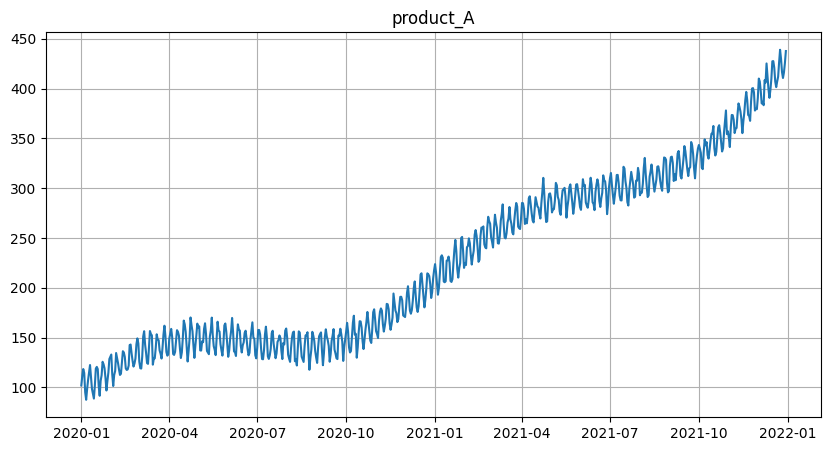

In [2]:
ts.plot()

In [3]:
from etna.analysis import plot_forecast
from etna.models import ProphetModel

HORIZON=100
model = ProphetModel()
pipeline = Pipeline(model=model, horizon=HORIZON)
pipeline.fit(ts)
forecast_ts_ProphetModel = pipeline.forecast()


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


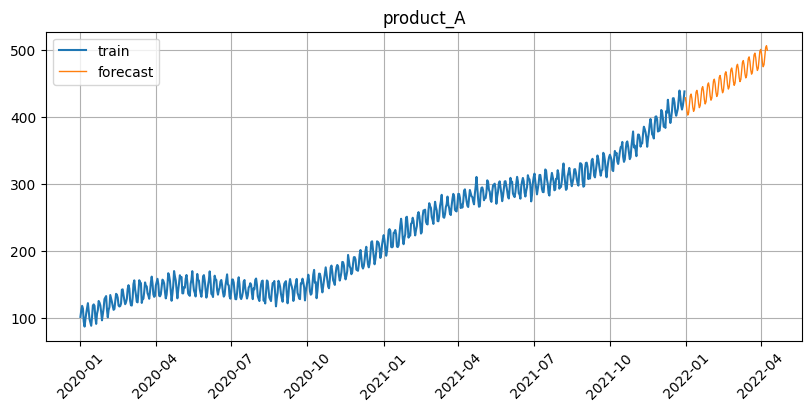

In [4]:
plot_forecast(
    forecast_ts=forecast_ts_ProphetModel,
    train_ts=ts,
    # n_train_samples=365,
    figsize=(8,4)
)

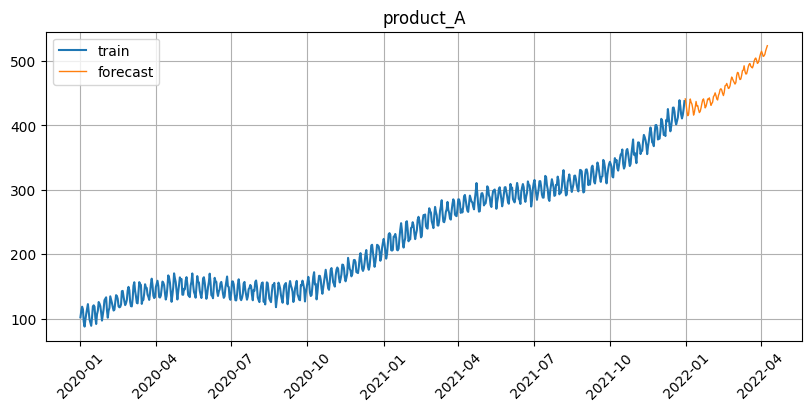

In [8]:
from etna.transforms import (
    LogTransform,
    TheilSenTrendTransform,
    FourierTransform,
    LagTransform,
    MeanTransform,
    DateFlagsTransform
)
from etna.models import CatBoostMultiSegmentModel
from etna.pipeline import Pipeline
from etna.metrics import MAE

# Шаг 1. Применяем трансформации
transforms = [
    LogTransform(in_column="target"),  # стабилизация дисперсии + линеаризация тренда
    TheilSenTrendTransform(in_column="target"),  # выделяем линейный тренд (можно оставить)
    FourierTransform(in_column="target", period=365.25, order=30),  # годовая сезонность
    FourierTransform(in_column="target", period=7, order=3),        # недельная сезонность
    LagTransform(in_column="target", lags=[1, 7, 14, 28, 365]),  # важные лаги
    MeanTransform(in_column="target", window=7),                 # скользящее среднее за неделю
    MeanTransform(in_column="target", window=30),                # за месяц
    DateFlagsTransform(),                                        # день недели, месяц и т.д.
]

# Шаг 2. Создаем pipeline
model = CatBoostMultiSegmentModel(
    iterations=500,
    random_state=42,
    thread_count=-1,
    # verbose=100
)

pipeline = Pipeline(
    model=model,
    transforms=transforms,
    horizon=HORIZON  # прогноз на 100 дней вперед
)

# Шаг 3. Обучение
pipeline.fit(ts)

# Шаг 4. Прогноз
forecast_ts = pipeline.forecast()

# Шаг 5. Визуализация
plot_forecast(
    forecast_ts=forecast_ts,
    train_ts=ts,
    # n_train_samples=365,
    figsize=(8,4)
)